# Mô hình Seq2Seq + Attention + Feature Engineering

- Ngày trong tuần
- Giờ trong ngày
- Lagged time
- StandardScale (optional Log transform)

> Chỉnh sửa **Config** để chạy các khung thời gian khác nhau (`CHUNK_TIME`)
> 
> Chỉnh `FEATURE_TO_PREDICT` để đổi dự đoán request-bytes

> Kaggle Link: https://www.kaggle.com/code/minhnvm2307/seq2seq-attention-auto-scaling/notebook

> Note: add input when running on kaggle: https://www.kaggle.com/datasets/minhnvm2307/auto-scaling-analysis-data

**Dự kiến thời gian chạy**: 3 phút

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import joblib

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [2]:
class Config:
    # Data
    DATA_PATH = '/kaggle/input/auto-scaling-analysis-data/train.csv'
    
    # Time series parameters
    CHUNK_TIME = "15min"
    FEATURE_TO_PREDICT = "request" # byte
    LOOKBACK_HOURS = 15
    FORECAST_HOURS = 1
    LAG_FEATURES = [31, 32, 34, 35] 
    
    # Model architecture
    HIDDEN_SIZE = 64
    NUM_LAYERS = 1
    DROPOUT = 0.0
    
    # Training
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3
    EPOCHS = 100
    GRAD_CLIP = 1.0
    WEIGHT_DECAY = 1e-6
    TRAIN_RATIO = 0.8
    
config = Config()

## 1. Data Loading

In [3]:
def load_data(filepath, feature="request"):
    """Load and prepare hourly time series"""
    print("Loading data...")
    df = pd.read_csv(filepath)
    
    # Parse timestamps
    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        format="%d/%b/%Y:%H:%M:%S %z"
    )
    
    # target 
    if feature == "request":
        df_series = df.set_index('timestamp').resample(config.CHUNK_TIME).size().reset_index(name='target')
    else:
        df_series = df.set_index('timestamp').resample(config.CHUNK_TIME)['bytes'].sum().reset_index()
        df_series.columns = ['timestamp', 'target']
    
    print(f"\nDataset Info:")
    print(f"  Total time chunk: {len(df_series)}")
    print(f"  Date range: {df_series['timestamp'].min()} to {df_series['timestamp'].max()}")
    print(f"  Total requests: {df_series['target'].sum():,}")
    
    return df_series

In [4]:
series = load_data(config.DATA_PATH, feature=config.FEATURE_TO_PREDICT)
series.head()

Loading data...

Dataset Info:
  Total time chunk: 5088
  Date range: 1995-07-01 00:00:00-04:00 to 1995-08-22 23:45:00-04:00
  Total requests: 2,934,961


,timestamp,target
0,1995-07-01 00:00:00-04:00,810
1,1995-07-01 00:15:00-04:00,945
2,1995-07-01 00:30:00-04:00,1006
3,1995-07-01 00:45:00-04:00,804
4,1995-07-01 01:00:00-04:00,750


### Decomposition

/tmp/ipykernel_23/1753277250.py:7: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df_season['target'] = df_season['target'].replace(0, method='ffill').fillna(1)


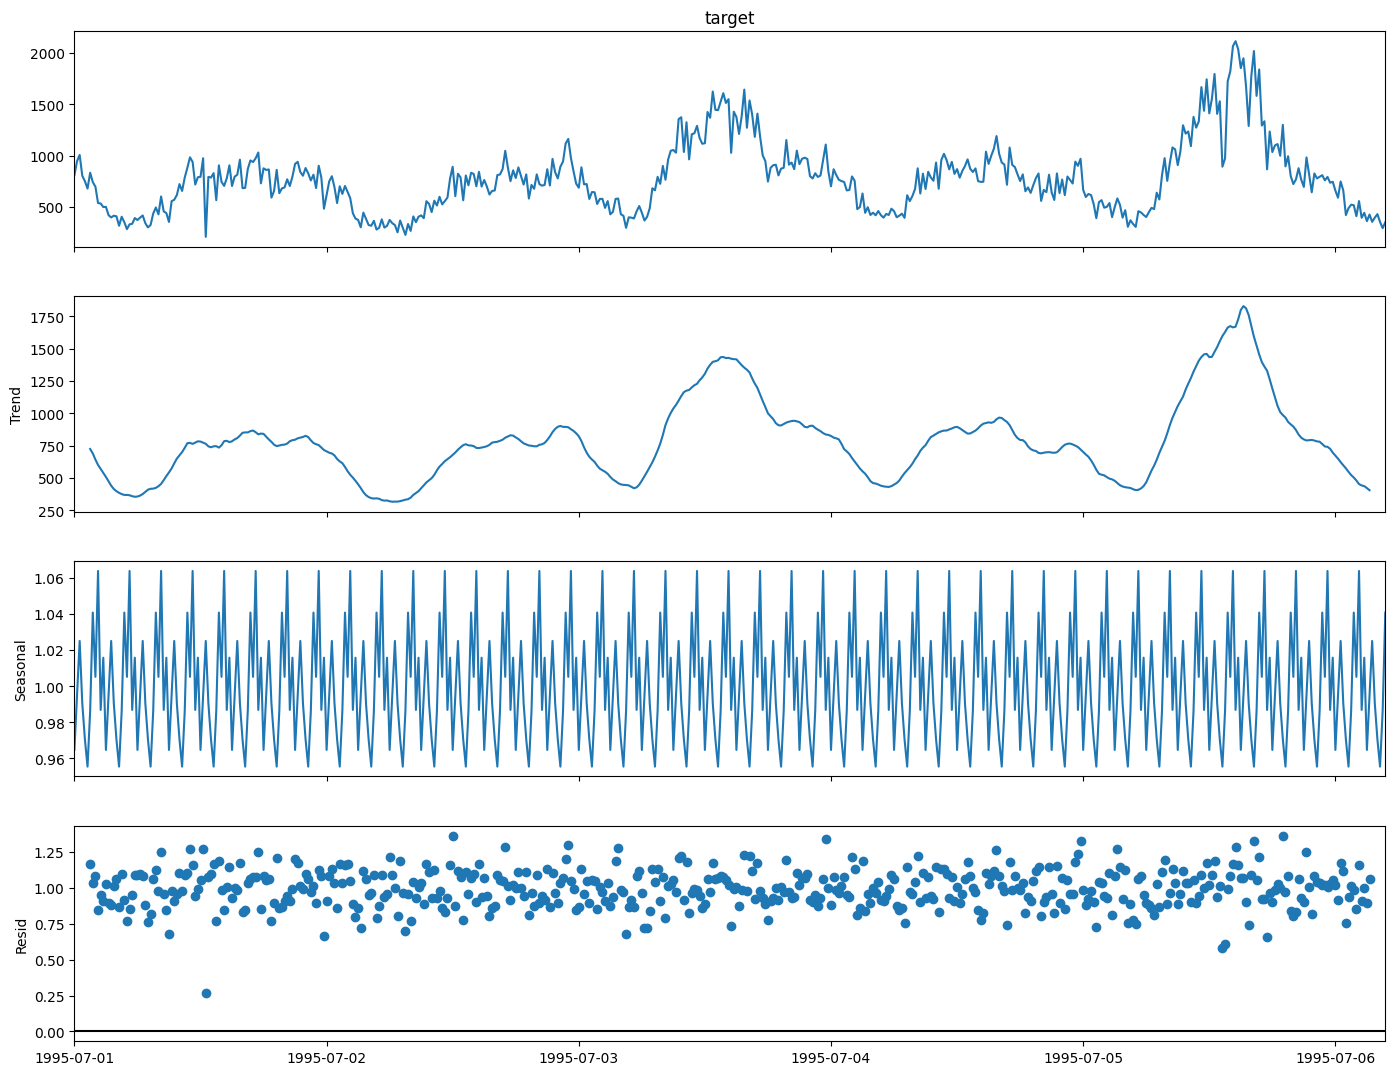

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df_season = series[:500].copy()
df_season.set_index('timestamp', inplace=True)

df_season['target'] = df_season['target'].replace(0, method='ffill').fillna(1)

result = seasonal_decompose(df_season['target'], model='multiplicative', period=12) 

fig = result.plot()
fig.set_size_inches(16, 12)
plt.show()

### Feature Engineering

In [6]:
def make_features(data: pd.DataFrame, mode='train', scaler=None):
    df = data.copy()
    
    if 'target_scaled' not in df.columns and mode=='train':
        scaler = RobustScaler()
        df['target_scaled'] = scaler.fit_transform(df[['target']])
    else:
        df['target_scaled'] = scaler.transform(df[['target']])
    
    # 3. Thông tin thời gian CƠ BẢN
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # Lag ngắn hạn: 1, 2, 3, 4 steps trước (1h với 15p window)
    for lag in config.LAG_FEATURES:
        df[f'lag_{lag}'] = df['target_scaled'].shift(lag)
    
    # 6. Binary features cho giờ cao điểm
    df['is_peak_hour'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    
    # Fill NaN values
    df = df.bfill().fillna(0)
    
    return df, scaler

In [7]:
df_featured, scaler = make_features(series, mode='train')
df_featured.head(3)

,timestamp,target,target_scaled,hour,dayofweek,is_weekend,lag_31,lag_32,lag_34,lag_35,is_peak_hour
0,1995-07-01 00:00:00-04:00,810,0.608654,0,5,1,0.608654,0.608654,0.608654,0.608654,0
1,1995-07-01 00:15:00-04:00,945,0.868269,0,5,1,0.608654,0.608654,0.608654,0.608654,0
2,1995-07-01 00:30:00-04:00,1006,0.985577,0,5,1,0.608654,0.608654,0.608654,0.608654,0


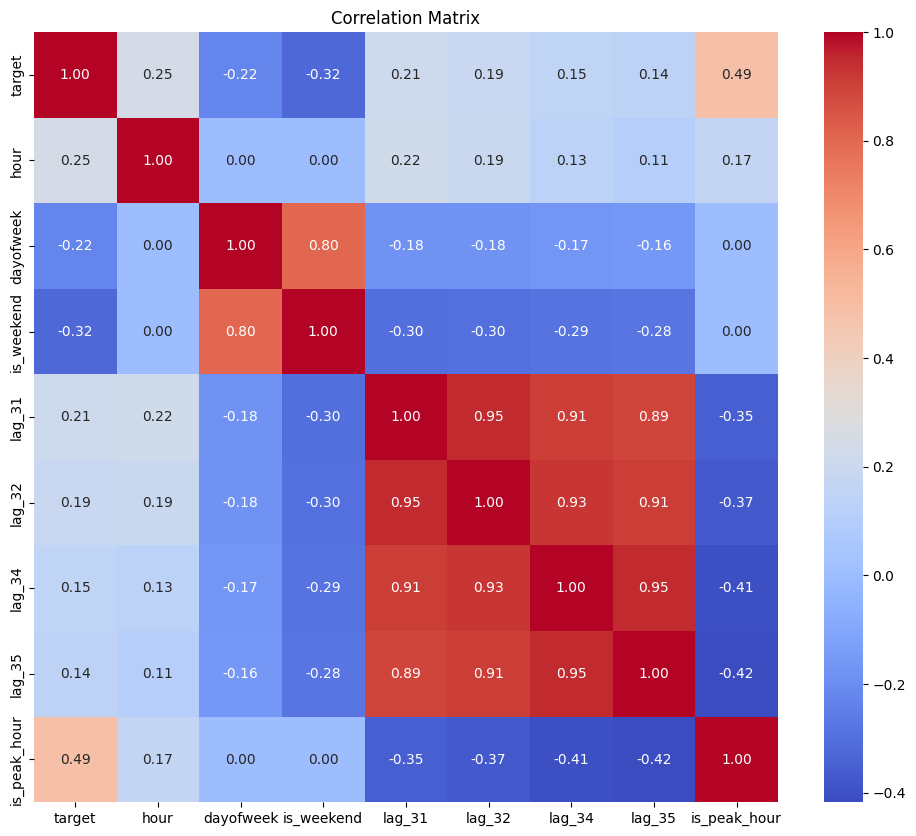

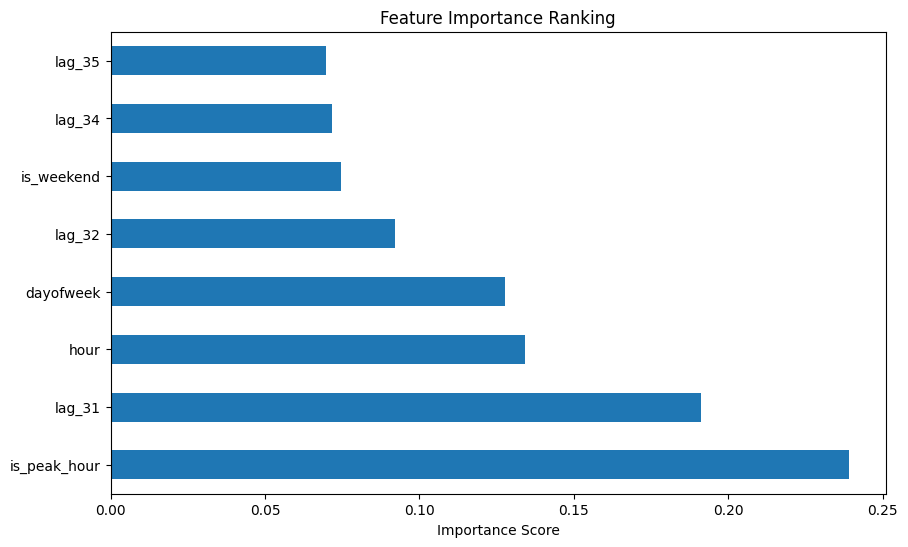

In [8]:
def analyze_features(df, target_col):
    """
    df: DataFrame chứa tất cả các features (bao gồm cả target)
    target_col: Tên cột mục tiêu (ví dụ: 'value')
    """
    # 1. Tính toán Correlation Matrix (Mối quan hệ tuyến tính)
    plt.figure(figsize=(12, 10))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

    # 2. Tính Feature Importance (Mối quan hệ phi tuyến & tác động thực tế)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Huấn luyện một model nhanh để xem độ quan trọng
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    importances.plot(kind='barh')
    plt.title("Feature Importance Ranking")
    plt.xlabel("Importance Score")
    plt.show()
    
    return importances


importances = analyze_features(df_featured.drop(columns=['timestamp', 'target_scaled'].copy()), target_col='target')

## 2. Dataset Class

In [9]:
class TrafficDataset(Dataset):
    def __init__(self, df, lookback=120, forecast_len=1):
        self.lookback = lookback
        self.forecast_len = forecast_len
        # Cột target đã log và scale
        self.target_values = df['target_scaled'].values.astype(np.float32)
        self.all_features = df.drop(columns=['timestamp', 'target']).values.astype(np.float32)

    def __len__(self):
        return (len(self.target_values) - self.lookback) // self.forecast_len

    def __getitem__(self, idx):
        x_feat = self.all_features[idx : idx + self.lookback]
        y_feat = self.all_features[idx + self.lookback : idx + self.lookback + self.forecast_len, 1:]
        
        y_target = self.target_values[idx + self.lookback : idx + self.lookback + self.forecast_len]
        
        return {
            'x_features': torch.tensor(x_feat),
            'y_features': torch.tensor(y_feat),
            'y_target': torch.tensor(y_target)
        }

## 3. Model Architecture

In [10]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def forward(self, encoder_outputs):
        # encoder_outputs: [batch, seq_len, hidden]
        attn_logits = self.attention(encoder_outputs)  # [batch, seq_len, 1]
        attn_weights = F.softmax(attn_logits, dim=1)
        context = torch.sum(attn_weights * encoder_outputs, dim=1)  # [batch, hidden]
        return context, attn_weights

class Seq2SeqModel(nn.Module):
    def __init__(self, input_size, encoder_hidden=267, decoder_hidden=267,
                 encoder_layers=1, decoder_layers=1, encoder_dropout=0.1,
                 decoder_dropout=0.03, output_size=1):
        super().__init__()
        
        self.encoder = nn.GRU(
            input_size=input_size, 
            hidden_size=encoder_hidden,
            num_layers=encoder_layers, 
            batch_first=True,
            dropout=encoder_dropout if encoder_layers > 1 else 0
        )

        self.attention = AttentionLayer(encoder_hidden)
        
        self.decoder_cell = nn.GRUCell(
            input_size=output_size + encoder_hidden,  
            hidden_size=decoder_hidden
        )
        
        self.fc_out = nn.Linear(decoder_hidden, output_size)
        self.decoder_output_dropout = nn.Dropout(decoder_dropout)
        self.encoder_hidden = encoder_hidden
        self.output_size = output_size
    
    def forward(self, x_features, y_features):
        batch_size = x_features.shape[0]
        forecast_len = y_features.shape[1]
        
        # 1. Encoding
        enc_outputs, hidden = self.encoder(x_features)
        
        # 2. Attention
        context, attn_weights = self.attention(enc_outputs)  # context: [batch, encoder_hidden]
        
        # 3. Decoding
        dec_hidden = hidden[-1, :, :]  # [batch_size, hidden_size]
        
        predictions = torch.zeros(batch_size, forecast_len, device=x_features.device)
        
        last_value = torch.zeros(batch_size, 1, device=x_features.device)
        
        # Decoding từng bước
        for t in range(forecast_len):
            dec_input = torch.cat([
                last_value,  # [batch, 1]
                context  # [batch, encoder_hidden]
            ], dim=1)  # [batch, 1 + encoder_hidden]
            
            # GRUCell forward
            dec_hidden = self.decoder_cell(dec_input, dec_hidden)
         
            pred_t = self.fc_out(self.decoder_output_dropout(dec_hidden))  # [batch, 1]
            predictions[:, t] = pred_t.squeeze(-1)
            
            last_value = pred_t 
        
        return predictions

## 4. Loss Functions

In [11]:
class SMAPELoss(nn.Module):
    def __init__(self, epsilon=0.1):
        super(SMAPELoss, self).__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        """
        Tính toán Smooth SMAPE để có thể backprop được.
        Công thức gốc: 2 * |y_pred - y_true| / (|y_pred| + |y_true|)
        Công thức smooth: tránh chia cho 0 bằng cách thêm epsilon vào mẫu số.
        """
        target = torch.expm1(target)
        pred = torch.expm1(pred)
        pred = pred.view_as(target)
        
        diff = torch.abs(pred - target)
        # max(sum, 0.5 + epsilon) để chặn dưới
        denominator = torch.abs(pred) + torch.abs(target) + self.epsilon
        smape = 2.0 * diff / denominator
        
        return torch.mean(smape)

In [12]:
def smape_metric(true, pred):
    # true, pred lúc này là mảng numpy đã expm1
    epsilon = 0.1
    summ = np.maximum(np.abs(true) + np.abs(pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(pred - true) / summ) * 2.0)
    return smape * 100

## 5. Training Functions

In [13]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in dataloader:
        # Lấy dữ liệu từ dictionary của Dataset
        x_features = batch['x_features'].to(device)
        y_features = batch['y_features'].to(device)
        y_target = batch['y_target'].to(device)
        
        # Forward pass
        # Giả sử model nhận cả x và y features (như kiến trúc Encoder-Decoder)
        predictions = model(x_features, y_features)
        
        # Loss
        loss = criterion(predictions, y_target)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient Clipping để tránh bùng nổ gradient
        if hasattr(config, 'GRAD_CLIP'):
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            x_features = batch['x_features'].to(device)
            y_features = batch['y_features'].to(device)
            y_target = batch['y_target'].to(device)
            
            # Forward
            predictions = model(x_features, y_features)

            loss = criterion(predictions, y_target)
            total_loss += loss.item()
            
            pred_original = torch.expm1(predictions).clamp(min=0)
            target_original = torch.expm1(y_target).clamp(min=0)
            
            all_preds.append(pred_original.cpu().numpy())
            all_targets.append(target_original.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Metric
    val_smape = smape_metric(all_targets, all_preds)
    val_mae = np.mean(np.abs(all_targets - all_preds))
    
    return total_loss / len(dataloader), val_smape, val_mae, all_preds, all_targets

## 6. Main Training

In [14]:
df_featured.head()

,timestamp,target,target_scaled,hour,dayofweek,is_weekend,lag_31,lag_32,lag_34,lag_35,is_peak_hour
0,1995-07-01 00:00:00-04:00,810,0.608654,0,5,1,0.608654,0.608654,0.608654,0.608654,0
1,1995-07-01 00:15:00-04:00,945,0.868269,0,5,1,0.608654,0.608654,0.608654,0.608654,0
2,1995-07-01 00:30:00-04:00,1006,0.985577,0,5,1,0.608654,0.608654,0.608654,0.608654,0
3,1995-07-01 00:45:00-04:00,804,0.597115,0,5,1,0.608654,0.608654,0.608654,0.608654,0
4,1995-07-01 01:00:00-04:00,750,0.493269,1,5,1,0.608654,0.608654,0.608654,0.608654,0


In [15]:
data = df_featured.drop(columns=['timestamp', 'target'])
display(data.head(3))

,target_scaled,hour,dayofweek,is_weekend,lag_31,lag_32,lag_34,lag_35,is_peak_hour
0,0.608654,0,5,1,0.608654,0.608654,0.608654,0.608654,0
1,0.868269,0,5,1,0.608654,0.608654,0.608654,0.608654,0
2,0.985577,0,5,1,0.608654,0.608654,0.608654,0.608654,0


In [16]:
# Split dataset: 80 train, 20 valid
split_idx =int(len(df_featured) * config.TRAIN_RATIO)
train_df = df_featured[:split_idx]
val_df = df_featured[split_idx:]
train_dataset = TrafficDataset(train_df, lookback=config.LOOKBACK_HOURS)
val_dataset = TrafficDataset(val_df, lookback=config.LOOKBACK_HOURS)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=True)

# Get input_size
sample = train_dataset[0]
input_size = sample['x_features'].shape[1]
print(f"Detected Input Features: {input_size}")

Detected Input Features: 9


In [17]:
# Model init
model = Seq2SeqModel(
    input_size=input_size,
    encoder_layers=config.NUM_LAYERS,
    decoder_layers=1,
    encoder_dropout=config.DROPOUT,
    decoder_dropout=0
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

criterion = SMAPELoss()
# criterion = nn.HuberLoss(delta=1.0)
optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)


Total parameters: 653,351


In [18]:
best_smape = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_smape': [], 'val_mae': []}

best_smape = float('inf')
for epoch in range(40):    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_smape, val_mae, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_smape'].append(val_smape)
    history['val_mae'].append(val_mae)
    
    if epoch % 5 == 0:
        print(f"Train Loss: {train_loss:.4f} | Val SMAPE: {val_smape:.2f}% | Val MAE: {val_mae:.2f}")

    # Lưu model tốt nhất dựa trên SMAPE
    if val_smape < best_smape:
        best_smape = val_smape
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"⭐ Saved New Best Model (SMAPE: {val_smape:.2f}%)")

Train Loss: 0.7838 | Val SMAPE: 39.53% | Val MAE: 0.28
⭐ Saved New Best Model (SMAPE: 39.53%)
⭐ Saved New Best Model (SMAPE: 27.64%)
⭐ Saved New Best Model (SMAPE: 24.62%)
⭐ Saved New Best Model (SMAPE: 21.15%)
Train Loss: 0.4589 | Val SMAPE: 20.47% | Val MAE: 0.17
⭐ Saved New Best Model (SMAPE: 20.47%)
⭐ Saved New Best Model (SMAPE: 19.73%)
Train Loss: 0.4320 | Val SMAPE: 20.31% | Val MAE: 0.17
Train Loss: 0.4372 | Val SMAPE: 22.21% | Val MAE: 0.18
Train Loss: 0.4181 | Val SMAPE: 24.56% | Val MAE: 0.21
Train Loss: 0.4168 | Val SMAPE: 20.13% | Val MAE: 0.17
⭐ Saved New Best Model (SMAPE: 19.70%)
Train Loss: 0.4092 | Val SMAPE: 20.26% | Val MAE: 0.17
Train Loss: 0.4054 | Val SMAPE: 19.62% | Val MAE: 0.16
⭐ Saved New Best Model (SMAPE: 19.62%)
⭐ Saved New Best Model (SMAPE: 19.59%)


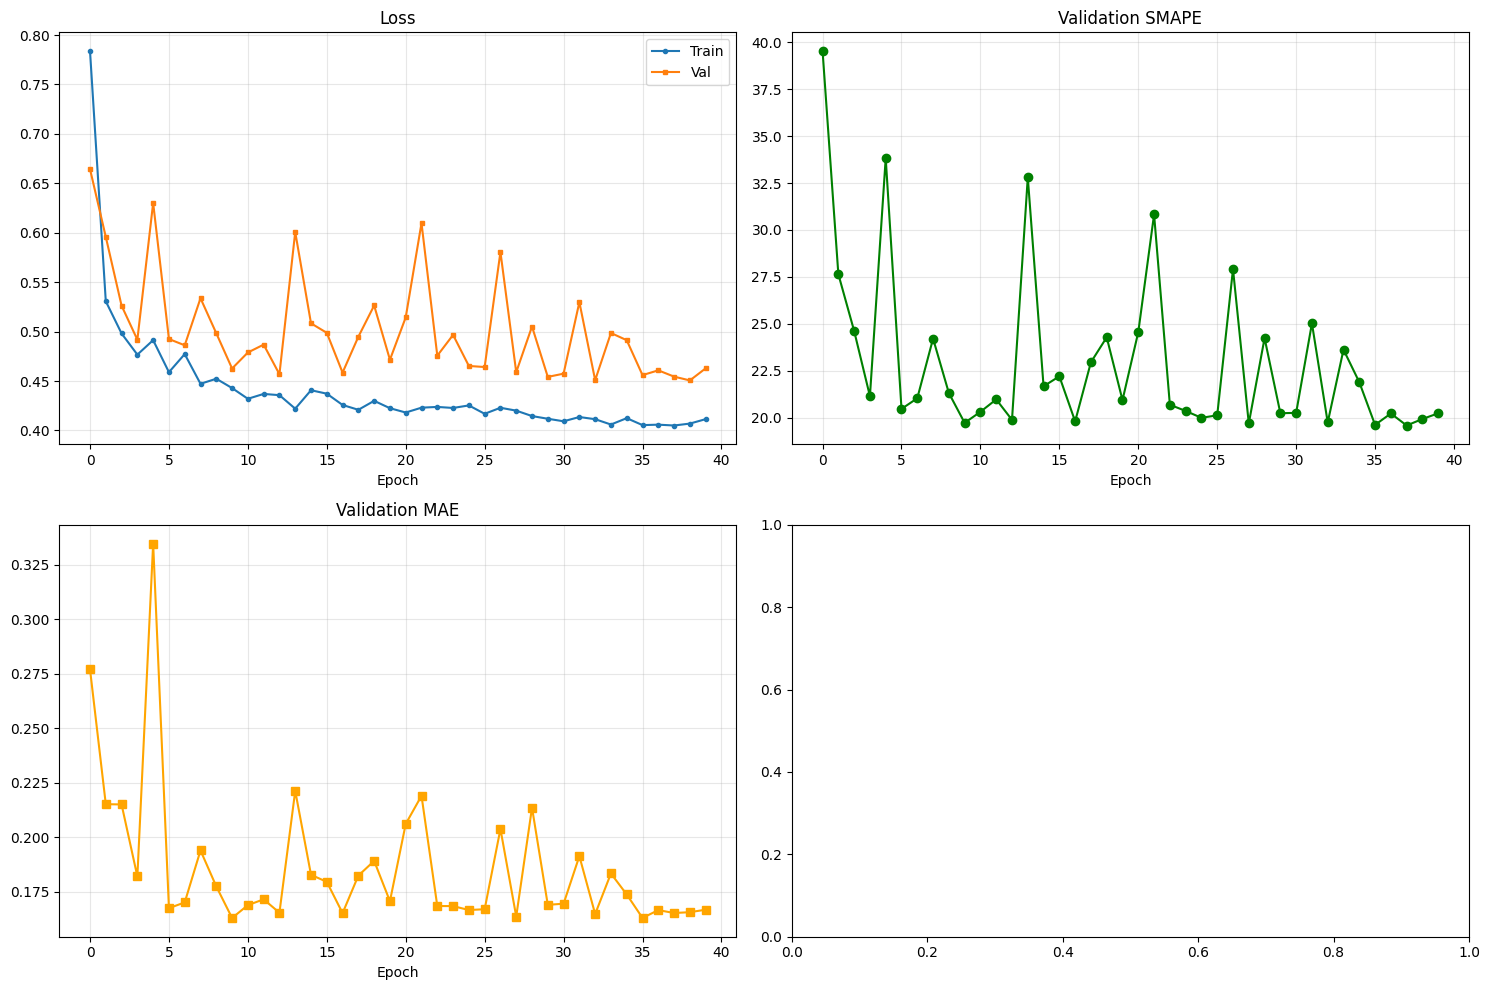

In [19]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history['val_loss'], label='Val', marker='s', markersize=3)
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['val_smape'], marker='o', color='green')
axes[0, 1].set_title('Validation SMAPE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history['val_mae'], marker='s', color='orange')
axes[1, 0].set_title('Validation MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation & Visualization

In [20]:
TEST_FILE = "/kaggle/input/auto-scaling-analysis-data/test.csv"
test_series = load_data(TEST_FILE, feature=config.FEATURE_TO_PREDICT)
test_series.head()

Loading data...

Dataset Info:
  Total time chunk: 864
  Date range: 1995-08-23 00:00:00-04:00 to 1995-08-31 23:45:00-04:00
  Total requests: 526,651


,timestamp,target
0,1995-08-23 00:00:00-04:00,443
1,1995-08-23 00:15:00-04:00,413
2,1995-08-23 00:30:00-04:00,313
3,1995-08-23 00:45:00-04:00,334
4,1995-08-23 01:00:00-04:00,190


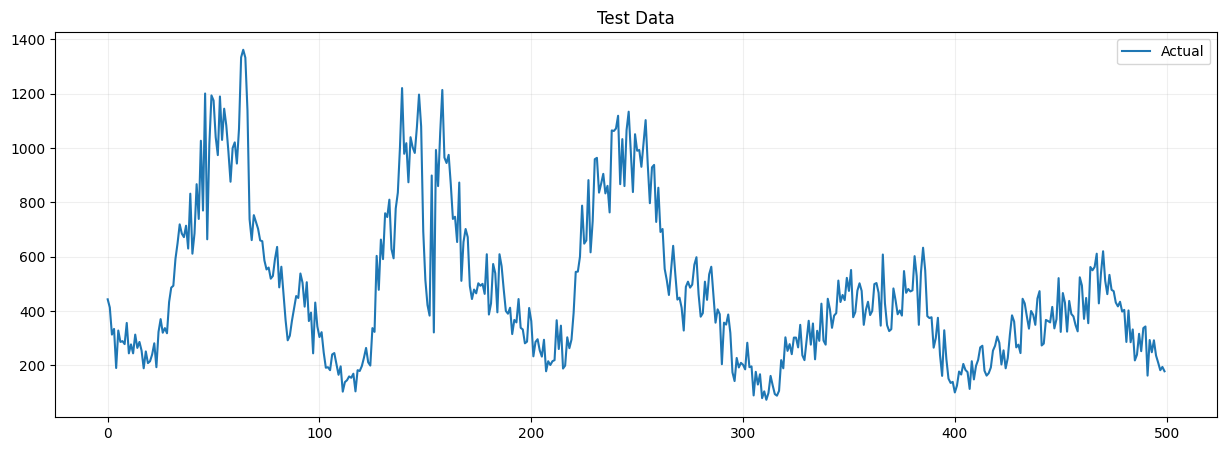

In [21]:
plt.figure(figsize=(15, 5))
plt.plot(test_series['target'][:500], label='Actual', color='#1f77b4')
plt.title("Test Data")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [22]:
padding_data = series.tail(config.LOOKBACK_HOURS)
full_test_series = pd.concat([padding_data, test_series], axis=0).reset_index(drop=True)

df_test_featured, _ = make_features(
    test_series, 
    mode='test', 
    scaler=scaler
)

test_dataset = TrafficDataset(
    df_test_featured, 
    lookback=config.LOOKBACK_HOURS
)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [23]:
def inference(model, dataloader, device, scaler):
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Test', leave=False)
        for batch in pbar:
            x_enc = batch['x_features'].to(device)
            y_enc = batch['y_features'].to(device)
            targets = batch['y_target'].to(device)
            
            # Forward pass
            outputs = model(x_enc, y_enc)

            # Denorm
            outputs = outputs.cpu().numpy()
            targets = targets.cpu().numpy()
            outputs = scaler.inverse_transform(outputs)
            targets = scaler.inverse_transform(targets)
            
            # Collect for analysis
            all_preds.append(outputs)
            all_targets.append(targets)
    
    # Concatenate all predictions and targets
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    return all_preds, all_targets

In [24]:
all_preds, all_targets = inference(model, test_loader, device, scaler)

Test:   0%|          | 0/14 [00:00<?, ?it/s]

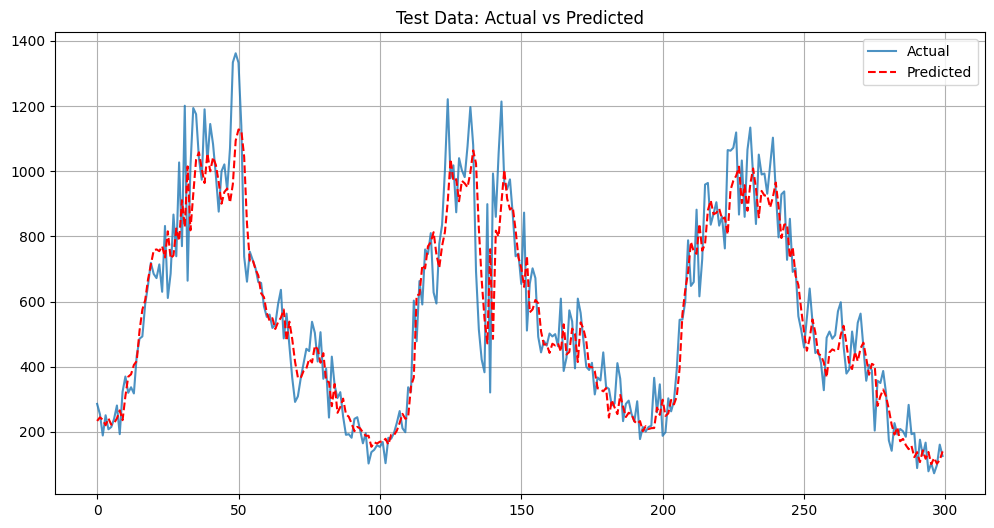

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(all_targets.flatten()[:300], label='Actual', color='#1f77b4', alpha=0.8)
plt.plot(all_preds.flatten()[:300], label='Predicted', color='red', linestyle='--')
plt.title("Test Data: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

actuals_inv = all_targets.flatten()
predictions_inv = all_preds.flatten()
mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)
mape, smape = calculate_mape(actuals_inv, predictions_inv)
# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 12993.3330
RMSE : 113.9883
MAE  : 83.0696
MAPE : 15.61%
SMAPE: 15.34%
R2   : 0.8978
------------------------------


## *Spike forecast Evaluation

In [27]:
from scipy.signal import find_peaks

class EventEvaluator:
    def __init__(self, tolerance=1):
        self.tolerance = tolerance

    def _match_events(self, true_indices, pred_indices):
        tp = 0  # True Positives
        matched_pred = set()
        matched_true = set()
        
        # Tạo danh sách các cặp ứng viên có thể match (khoảng cách <= tolerance)
        candidates = []
        for t_idx in true_indices:
            for p_idx in pred_indices:
                dist = abs(t_idx - p_idx)
                if dist <= self.tolerance:
                    candidates.append((dist, t_idx, p_idx))
        
        # Sắp xếp ưu tiên các cặp gần nhau nhất trước
        candidates.sort(key=lambda x: x[0])
        
        # Duyệt và ghép cặp (Greedy matching)
        for _, t_idx, p_idx in candidates:
            if t_idx not in matched_true and p_idx not in matched_pred:
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                tp += 1
                
        fn = len(true_indices) - len(matched_true) # Có thật mà không đoán được
        fp = len(pred_indices) - len(matched_pred) # Đoán mà không có thật
        
        return tp, fp, fn

    def _calculate_metrics(self, tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        return {
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "TP": tp, "FP": fp, "FN": fn
        }

    def evaluate_spikes(self, y_true, y_pred, threshold_std=3):
        # Tính ngưỡng dựa trên dữ liệu thật
        mean = np.mean(y_true)
        std = np.std(y_true)
        limit = mean + threshold_std * std
        
        true_spikes = np.where(y_true > limit)[0]
        pred_spikes = np.where(y_pred > limit)[0]
        
        tp, fp, fn = self._match_events(true_spikes, pred_spikes)
        return self._calculate_metrics(tp, fp, fn)

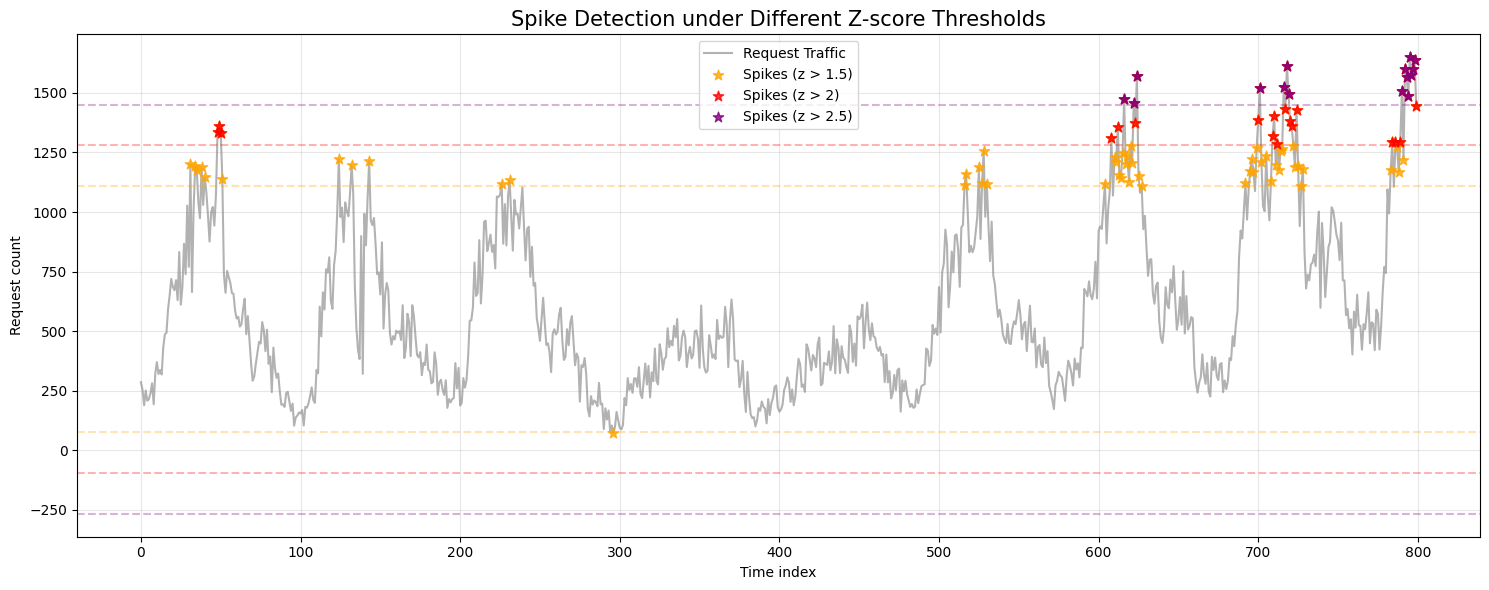

In [28]:
y = all_targets[:800, 0]
x = np.arange(len(y))

mean = np.mean(y)
std = np.std(y)

thresholds = [1.5, 2, 2.5]
colors = ['orange', 'red', 'purple']

plt.figure(figsize=(15, 6))
plt.plot(x, y, label='Request Traffic', color='gray', alpha=0.6)

for thres, color in zip(thresholds, colors):
    spikes = np.where(np.abs(y - mean) > thres * std)[0]

    plt.scatter(
        x[spikes],
        y[spikes],
        s=60,
        marker='*',
        color=color,
        alpha=0.8,
        label=f'Spikes (z > {thres})',
        zorder=4
    )

    # Vẽ ngưỡng
    plt.axhline(mean + thres * std, color=color, linestyle='--', alpha=0.3)
    plt.axhline(mean - thres * std, color=color, linestyle='--', alpha=0.3)

plt.title("Spike Detection under Different Z-score Thresholds", fontsize=15)
plt.xlabel("Time index")
plt.ylabel("Request count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
from pprint import pprint

evaluator = EventEvaluator(tolerance=2)

spike_results = {}

for thres in thresholds:
    metrics = evaluator.evaluate_spikes(
        actuals_inv.flatten(),
        predictions_inv.flatten(),
        threshold_std=thres
    )
    spike_results[f"z>{thres}"] = metrics

print("\n--- SPIKE DETECTION BY Z-SCORE ---")
pprint(spike_results)


--- SPIKE DETECTION BY Z-SCORE ---
{'z>1.5': {'F1-Score': 0.7919463087248322,
           'FN': 29,
           'FP': 2,
           'Precision': 0.9672131147540983,
           'Recall': 0.6704545454545454,
           'TP': 59},
 'z>2': {'F1-Score': 0.6666666666666666,
         'FN': 20,
         'FP': 0,
         'Precision': 1.0,
         'Recall': 0.5,
         'TP': 20},
 'z>2.5': {'F1-Score': 0.5454545454545455,
           'FN': 9,
           'FP': 1,
           'Precision': 0.8571428571428571,
           'Recall': 0.4,
           'TP': 6}}


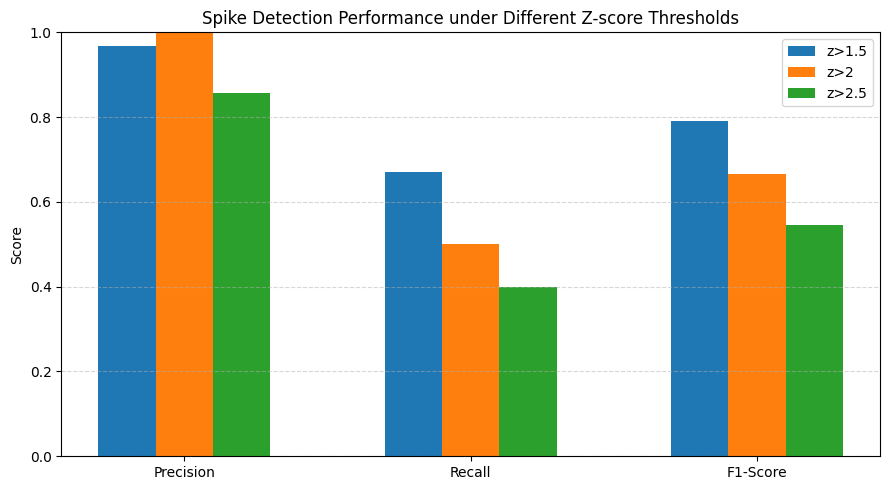

In [30]:
metric_names = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(metric_names))
width = 0.2

plt.figure(figsize=(9,5))

for i, (label, vals) in enumerate(spike_results.items()):
    scores = [vals[m] for m in metric_names]
    plt.bar(x + i * width, scores, width, label=label)

plt.xticks(x + width, metric_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Spike Detection Performance under Different Z-score Thresholds")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## *Rolling Forecast Eval

In [31]:
def run_rolling_inference(model, df_test_featured, scaler, config, device, forecast_step):
    model.eval()
    
    # Chuẩn bị dữ liệu đầu vào gốc
    input_data = df_test_featured.drop(columns=['timestamp', 'target']).values
    y_features_full = df_test_featured.drop(columns=['timestamp', 'target', 'target_scaled']).values

    all_preds_scaled = []
    
    num_samples = len(df_test_featured) - config.LOOKBACK_HOURS - forecast_step 
    with torch.no_grad():
        for start_idx in range(0, num_samples, forecast_step):
            
            # Reset x_input về trạng thái ban đầu của window hiện tại
            curr_window = input_data[start_idx : start_idx + config.LOOKBACK_HOURS].copy()
            x_input = torch.tensor(curr_window, dtype=torch.float32).unsqueeze(0).to(device)
            
            current_window_preds = []
            
            # Dự báo cuốn chiếu forecast_step bước
            for step in range(forecast_step):
                # Lấy y_feature tương ứng với thời điểm cần dự báo (ngay sau window hiện tại)
                y_feat = y_features_full[start_idx + config.LOOKBACK_HOURS + step].reshape(1, 1, -1)
                y_features_input = torch.tensor(y_feat, dtype=torch.float32).to(device)
                
                # Forward pass
                pred_scaled = model(x_input, y_features_input)
                if isinstance(pred_scaled, tuple): pred_scaled = pred_scaled[0]
                
                val_scaled = pred_scaled.cpu().numpy().flatten()[0]
                current_window_preds.append(val_scaled)
                
                # --- LOGIC ROLLING ---
                next_row = input_data[start_idx + config.LOOKBACK_HOURS + step].copy()
                # Ghi đè giá trị dự báo vào vị trí target 
                next_row[0] = val_scaled 
                next_row_t = torch.tensor(next_row, dtype=torch.float32).view(1, 1, -1).to(device)
                x_input = torch.cat([x_input[:, 1:, :], next_row_t], dim=1)
            
            all_preds_scaled.append(current_window_preds)

    preds_scaled_final = np.array(all_preds_scaled).flatten().reshape(-1, 1)
    
    dummy_p = np.zeros((len(preds_scaled_final), scaler.n_features_in_))
    dummy_p[:, 0] = preds_scaled_final[:, 0]
    preds = scaler.inverse_transform(dummy_p)[:, 0]
    
    targets_raw = df_test_featured['target'].values[config.LOOKBACK_HOURS : config.LOOKBACK_HOURS + len(preds)]
    
    return preds, targets_raw

# Thực thi
all_preds, all_targets = run_rolling_inference(model, df_test_featured, scaler, config, device, forecast_step=30)

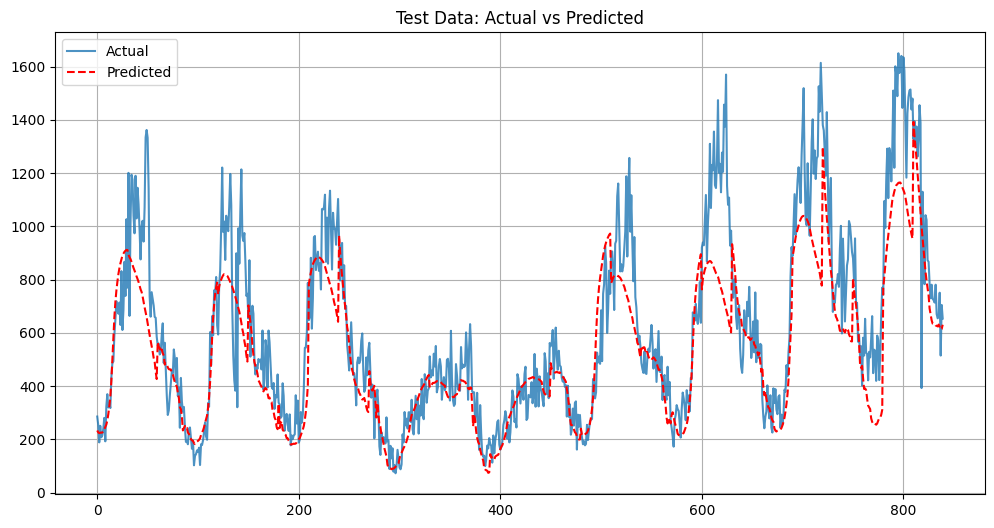

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(all_targets.flatten()[:], label='Actual', color='#1f77b4', alpha=0.8)
plt.plot(all_preds.flatten()[:], label='Predicted', color='red', linestyle='--')
plt.title("Test Data: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
actuals_inv = all_targets.flatten()
predictions_inv = all_preds.flatten()
mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

mape, smape = calculate_mape(actuals_inv, predictions_inv)

# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 36857.2025
RMSE : 191.9823
MAE  : 133.8106
MAPE : 21.29%
SMAPE: 22.98%
R2   : 0.7128
------------------------------
